# Training Plots

Notebook for visualizing training curves from experiment metrics (compare/merge runs, optional best-epoch annotation).
Extend later with validation/test metrics, confusion matrix, etc.

Configure experiments root, experiment names, and output below.

## Config

Set experiments root, which runs to compare, merge behavior, and optional best-metric annotation.

In [1]:
import os
import sys
from pathlib import Path

# Ensure repo root is on path so "from utils.visualize_metrics" works when run from notebooks/
_repo_root = Path.cwd()
if (_repo_root / "utils").is_dir():
    pass
elif (_repo_root.parent / "utils").is_dir():
    _repo_root = _repo_root.parent
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

# Root folder containing experiment directories
EXPERIMENTS_ROOT = Path(os.environ.get("BRIDGE_EXPERIMENTS_ROOT", str(_repo_root / "experiments")))

# Experiment folder names to compare (e.g. two runs for merge)
EXPERIMENT_NAMES = [
    "bridge-base-all-data-v0",
    "bridge-base-all-data-v1",
]

# Version number per experiment (same length as EXPERIMENT_NAMES)
VERSIONS = [0, 0]

# When True and exactly two experiments, merge into one timeline (v0 epochs then v1 later epochs)
MERGE_RESUMED = True

# Output directory and filename
try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _nb_dir = os.getcwd()
if os.path.basename(_nb_dir) != "notebooks":
    _nb_dir = os.path.join(_nb_dir, "notebooks")
OUTPUT_DIR = Path(_nb_dir) / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FILENAME = "training_curves_merged.png"

# Validation metric to annotate with best epoch (e.g. "val_deck_iou" or "deck_iou"). Set to None to skip.
ANNOTATE_BEST_METRIC = "val_deck_iou"


## Merged training curves

Plot training curves from the configured experiments. Uses `utils.visualize_metrics.plot_metrics_compare`.

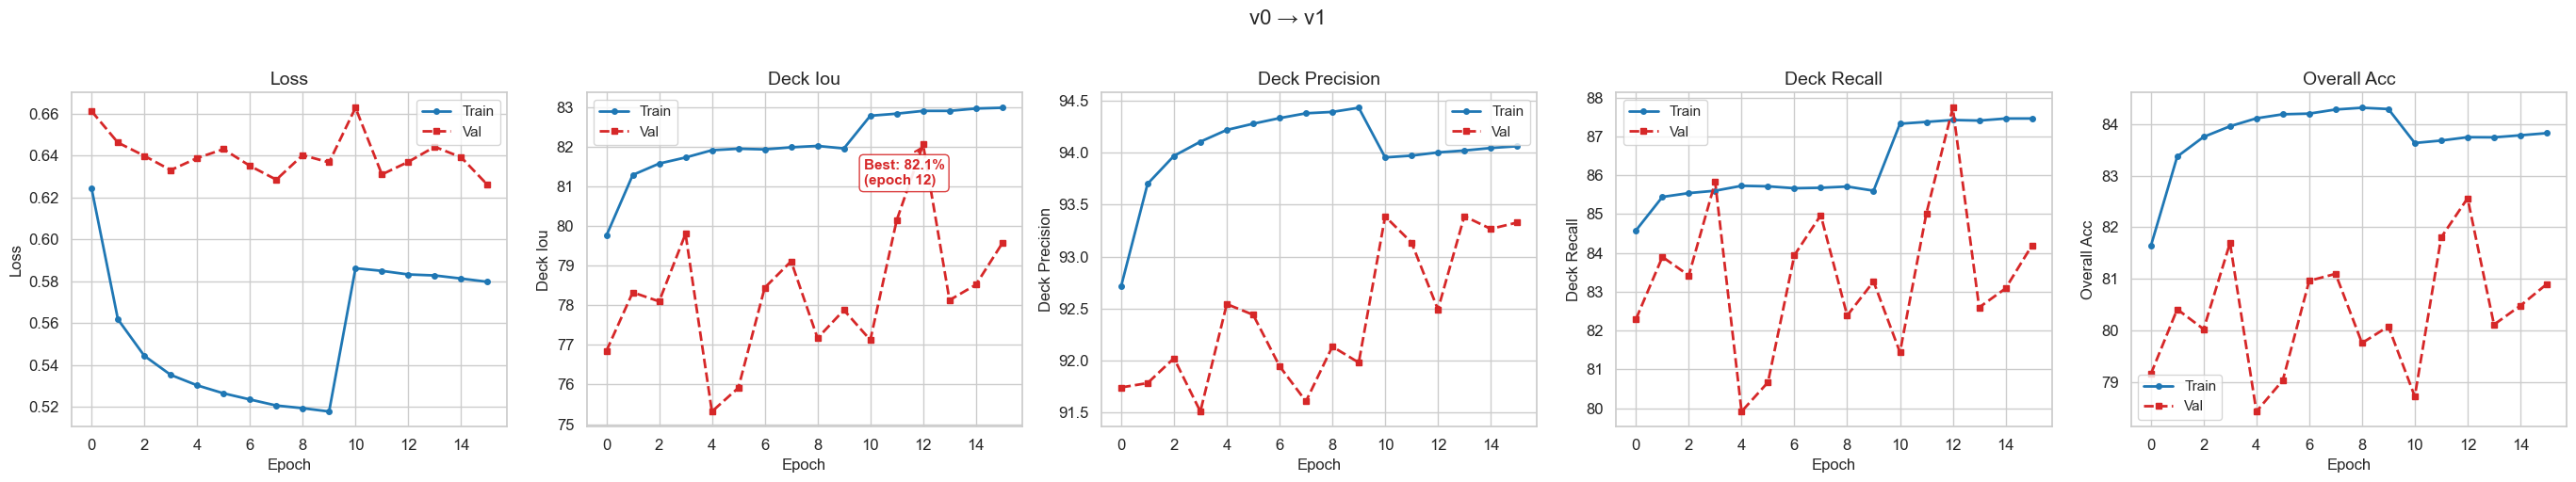

Comparison curves saved to: /Users/bbhandar/Work/ERT/git/bridge_classification/notebooks/outputs/training_curves_merged.png
Saved: /Users/bbhandar/Work/ERT/git/bridge_classification/notebooks/outputs/training_curves_merged.png


In [2]:
from utils.visualize_metrics import plot_metrics_compare

metrics_paths_with_labels = [
    (EXPERIMENTS_ROOT / exp / f"version_{v}" / "metrics.csv", exp)
    for exp, v in zip(EXPERIMENT_NAMES, VERSIONS)
]

missing = [p for p, _ in metrics_paths_with_labels if not p.exists()]
if missing:
    raise FileNotFoundError(f"Metrics files not found: {missing}")

out_path = OUTPUT_DIR / OUTPUT_FILENAME
plot_metrics_compare(
    metrics_paths_with_labels,
    out_path,
    merge_resumed=MERGE_RESUMED,
    annotate_best_metric=ANNOTATE_BEST_METRIC,
    show=True,
)
print(f"Saved: {out_path}")
